# Exercise: Numerical Verification of Wien’s Displacement Law

In this exercise, you will verify Wien’s displacement law numerically.

Wien’s law states that the wavelength of maximum emission of a blackbody spectrum satisfies

$
\lambda_{\max} T = b,
$

where $b$ is Wien’s displacement constant.

Your goal is to:

- Implement Planck’s radiation law  
- Determine the peak wavelength for different temperatures  
- Perform a linear fit  
- Extract Wien’s constant from the slope  


Define the following physical constants in SI units:

- Planck constant $h$
- Speed of light $c$
- Boltzmann constant $k_B$

These constants will be used to compute the blackbody spectrum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.constants as con

# Physical constants (SI units)
h  = con.Planck
c  = con.c
kB = con.k


Implement the function (Planck's law of black-body radiation)

$
B(\lambda, T) =
\frac{2 h c^2}{\lambda^5}
\frac{1}{\exp\!\left(\frac{h c}{\lambda k_B T}\right)-1}.
$

The function should take a wavelength array $\lambda$ and a temperature $T$ as input and return the spectral radiance.

1. Create a wavelength grid between 100 nm and 3000 nm.

In [4]:
lam = np.linspace(100e-9, 3000e-9, 5000)
temperatures = [3000, 4000, 5000, 6000]

2. Define the function mentioned above.

In [25]:
def planck_lambda(lam: np.ndarray, T: float) -> np.ndarray:
    return (2 * h * np.square(c))/(np.pow(lam, 5)) * (1/np.expm1((h*c)/(lam * kB * T)))

In [26]:
assert len(planck_lambda(lam, temperatures[0])) == 5000, "Length of array not correct"
assert min(planck_lambda(lam, temperatures[0])) == 0.0176806737832943, "Smallest element not correct"
assert max(planck_lambda(lam, temperatures[0])) == 995248854084.3911, "Largest element not correct"

3. Plot the resulting function using your ``linspace`` lambda for increasing temperatures.

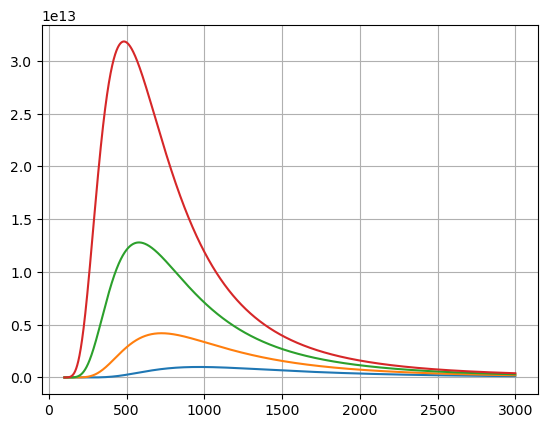

In [29]:
fig = plt.figure()
for temp in temperatures:
    plt.plot(lam * 1e9, planck_lambda(lam, temp))
plt.grid()
plt.show()

If everything is correct:

- The peak shifts toward smaller wavelengths as temperature increases.
- The intensity increases strongly with temperature.

## Find Peaks

For each temperature:

1. Compute $B(\lambda, T)$.
2. Determine the wavelength at which the function reaches its maximum.
3. Store the corresponding value $\lambda_{\max}$.

Use `np.argmax` to find the maximal values (Peaks) numerically.
Here we have already defined a new ``np.linspace`` object to use for temperatures.
Fill the given ``lambda_max_values`` list with the corresponding peaks for every temperature in T_values.

In [34]:
T_values = np.linspace(2500, 8000, 10)
lambda_max_values = []

for t_v in T_values:
    B = planck_lambda(lam, t_v)
    lambda_max = lam[np.argmax(B)]
    lambda_max_values.append(lambda_max)

In [33]:
assert len(lambda_max_values) == len(T_values), "Length of array not correct"
assert min(lambda_max_values) == 3.6221244248849775e-07, "Minimal elemment not correct"
assert max(lambda_max_values) == 1.1592918583716746e-06, "maximal element not correct"

Wien’s law predicts

$
\lambda_{\max} = b \cdot \frac{1}{T}.
$

1. Plot $\lambda_{\max}$ versus $1/T$.  
2. Perform a linear fit using `np.polyfit`.  
3. Interpret the slope as Wien’s constant $b$ and name this fitted b ``b_fit``.

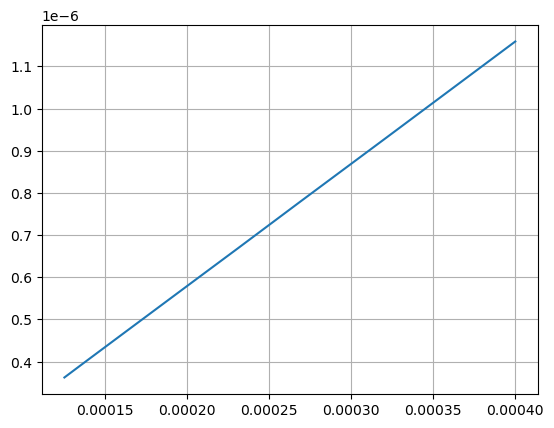

Theoretical value:      b ≈ 2.898e-3 m K


In [52]:
invT = 1 / T_values
coeff = np.polyfit(invT, lambda_max_values, 1)
b_fit = coeff[0]
fit_line = np.polyval(coeff, invT)

fig = plt.figure()
plt.plot(invT, np.array(lambda_max_values))
plt.grid()
plt.show()

print("Theoretical value:      b ≈ 2.898e-3 m K")

In [53]:
assert math.isclose(b_fit, 2.898e-3, rel_tol=1e-3), "Fitted value not correct/close enough"